# Week 4 — Measure (Lantern AI)

Milestone 4 of the MKT 282 capstone. Close fielding, QA the sample, read HB partworths into **importances and median WTP**, hand-verify Exhibit 10, score the silicon twin against sealed predictions, and verdict the three Week-1 hypotheses.

**This run uses the practice CBC (n = 400)** — the sanctioned calibration set on the same Exhibit 8 grid. It is *not* a substitute for your Discover export unless the teaching team authorizes fallback. Point `UTILITIES_PATH` at your HB file when fielding closes.

**Answers for the memo**

1. **QA.** n = 400 → drop 9 with RLH < 0.45 → **391**. Occupation mix 54.7 / 22.8 / 22.5 vs 56 / 21 / 23 quota. No timestamps in the practice file, so no speeder screen.
2. **Read.** Price 41.9% of importance. Next: assistant scope 15.6%, usage 14.3%, integrations 12.0%, privacy 11.1%, household 5.2%. Median WTP: life-admin vs answers **$7.37**; no-training vs standard **$4.00**; Vault vs standard **$6.39**; household **$2.32**.
3. **Hand-verify.** Respondent 1 Vault vs Standard = **$13.60** (matches the workbook). Respondents 1–10 first-choice of {Home $20, Pro $24, None} = 1 Home, 1 Pro, 8 None.
4. **Silicon.** Human actuals to score against: top-2 = Price, Assistant scope; median Vault-vs-Standard WTP = $6.39; $20-clone take = **1.0%**. Week 3 preregistration is still unsealed — do not backfill.
5. **Hypotheses.** H1 (privacy-sensitive professionals pay ≥ $8 for no-training) **complicated** ($7.94). H2 (life-admin ≥ $5) **confirmed** ($7.37). H3 (household ≥ $5) **killed** ($2.32).


## 0. Setup and data

Recipes are Fact Pack / practice-workbook dictionary: WTP is the **median** of per-respondent $(u_b - u_a) / |\beta_{\$10}| \times 10$. Importance is each attribute's partworth range over the sum of ranges, with price range $= |\beta_{\$10}| \times 3$ for the $6–$36 span. Simulation is **first choice**, not share-of-preference.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_columns", 20)

DATA_DIR = Path("Data")
# Swap this to your Discover HB export when fielding closes.
UTILITIES_PATH = DATA_DIR / "Lantern_Practice_CBC_Data.xlsx"
RLH_FLOOR = 0.45
QUALIFIED_POOL = 124_000
QUOTA = {"professional": 0.564, "student": 0.213, "other": 0.227}

ATTR = {
    "Usage": ["usage_1", "usage_2", "usage_3"],
    "Privacy": ["priv_1", "priv_2", "priv_3"],
    "Assistant scope": ["agents_1", "agents_2", "agents_3"],
    "Integrations": ["integ_1", "integ_2", "integ_3"],
    "Household seats": ["seats_1", "seats_2"],
}
LEVEL_LABELS = {
    "usage_1": "Light", "usage_2": "Standard", "usage_3": "Max",
    "priv_1": "Standard (may train)", "priv_2": "No-training", "priv_3": "Vault",
    "agents_1": "Answers only", "agents_2": "Life-admin", "agents_3": "Autopilot",
    "integ_1": "None", "integ_2": "Email + calendar", "integ_3": "Full suite",
    "seats_1": "Individual", "seats_2": "Household",
}
STEPS = [
    ("Usage Light → Standard", "usage_2", "usage_1"),
    ("Usage Standard → Max", "usage_3", "usage_2"),
    ("Usage Light → Max", "usage_3", "usage_1"),
    ("Privacy Standard → No-training", "priv_2", "priv_1"),
    ("Privacy No-training → Vault", "priv_3", "priv_2"),
    ("Privacy Standard → Vault", "priv_3", "priv_1"),
    ("Agents Answers → Life-admin", "agents_2", "agents_1"),
    ("Agents Life-admin → Autopilot", "agents_3", "agents_2"),
    ("Agents Answers → Autopilot", "agents_3", "agents_1"),
    ("Integrations None → Email+cal", "integ_2", "integ_1"),
    ("Integrations Email+cal → Full suite", "integ_3", "integ_2"),
    ("Integrations None → Full suite", "integ_3", "integ_1"),
    ("Seats Individual → Household", "seats_2", "seats_1"),
]


def wtp_step(frame, col_b, col_a):
    return (frame[col_b] - frame[col_a]) / frame["Price_per_+$10"].abs() * 10


def importances(frame):
    ranges = {name: frame[cols].max(axis=1) - frame[cols].min(axis=1) for name, cols in ATTR.items()}
    ranges["Price"] = frame["Price_per_+$10"].abs() * 3.0
    R = pd.DataFrame(ranges, index=frame.index)
    return R.div(R.sum(axis=1), axis=0)


def plan_utility(row, usage, priv, agents, integ, seats, price):
    return (
        row[usage] + row[priv] + row[agents] + row[integ] + row[seats]
        + (price / 10) * row["Price_per_+$10"]
    )


def median_wtp_table(frame):
    rows = []
    for label, b, a in STEPS:
        w = wtp_step(frame, b, a)
        rows.append(
            {
                "step": label,
                "n": int(len(frame)),
                "median_$": w.median(),
                "p25": w.quantile(0.25),
                "p75": w.quantile(0.75),
                "share_positive": (w > 0).mean(),
            }
        )
    return pd.DataFrame(rows)


In [2]:
util = pd.read_excel(UTILITIES_PATH, sheet_name="Utilities")
demo = pd.read_excel(UTILITIES_PATH, sheet_name="Demographics")
raw = util.merge(demo, on="Respondent_ID")
print(f"Loaded {UTILITIES_PATH.name}: n = {len(raw):,}  RLH median = {raw.RLH.median():.3f}")
raw.head()


Loaded Lantern_Practice_CBC_Data.xlsx: n = 400  RLH median = 0.618


,Respondent_ID,RLH,usage_1,usage_2,usage_3,priv_1,priv_2,priv_3,agents_1,agents_2,...,seats_2,Price_per_+$10,NONE,age_band,occupation,income_band,paid_ai_subs_now,ai_usage_freq,privacy_concern_1to5,household_size
0,1,0.519,-0.3507,0.1795,0.1712,-0.5205,0.1185,0.4020,-0.6009,0.1312,...,0.0645,-0.6785,-1.0260,25-34,professional,$50-100K,none,few times/week,3,1
1,2,0.555,-0.7902,0.0087,0.7815,-0.1588,0.1003,0.0585,-0.3791,0.1949,...,0.0453,-1.0650,-0.4968,18-24,professional,$50-100K,one,daily,3,3
2,3,0.458,-0.3105,-0.0742,0.3847,-0.5009,0.0201,0.4808,-0.8609,-0.0211,...,0.4462,-1.1733,-1.5971,18-24,student,$100-150K,none,weekly or less,3,2
3,4,0.630,-0.3876,-0.1058,0.4934,-0.4845,-0.0188,0.5033,-0.8266,-0.0562,...,0.6783,-1.2468,0.1574,45-54,other,>$150K,none,few times/week,3,3
4,5,0.426,-0.4445,-0.2771,0.7216,-0.1890,-0.0546,0.2436,-0.2259,-0.0695,...,0.0317,-0.7917,2.3901,25-34,professional,$50-100K,none,daily,2,1


## 1. Fielding close, QA, sample vs quota

Practice HB has no dwell-time or straightline flags. The dictionary screen is **RLH < 0.45**. When your Discover file arrives, add speeders (e.g. < 3 minutes on 12 tasks) and straightliners (same concept position every task) to this log.


In [3]:
qa_drop = raw[raw.RLH < RLH_FLOOR][["Respondent_ID", "RLH", "occupation", "ai_usage_freq"]].copy()
qa_drop["reason"] = f"RLH < {RLH_FLOOR}"
keep = raw[raw.RLH >= RLH_FLOOR].copy()
print(f"Raw n = {len(raw)}  dropped = {len(qa_drop)}  analytic n = {len(keep)}")
print(f"Gate n ≥ 60: {'PASS' if len(keep) >= 60 else 'FAIL'}")
qa_drop


Raw n = 400  dropped = 9  analytic n = 391
Gate n ≥ 60: PASS


,Respondent_ID,RLH,occupation,ai_usage_freq,reason
4,5,0.426,professional,daily,RLH < 0.45
34,35,0.420,professional,daily,RLH < 0.45
64,65,0.420,professional,few times/week,RLH < 0.45
76,77,0.420,professional,few times/week,RLH < 0.45
192,193,0.420,professional,daily,RLH < 0.45
242,243,0.420,professional,weekly or less,RLH < 0.45
255,256,0.443,professional,few times/week,RLH < 0.45
256,257,0.448,professional,few times/week,RLH < 0.45
390,391,0.420,professional,few times/week,RLH < 0.45


In [4]:
profile = (
    keep["occupation"]
    .value_counts()
    .rename("n")
    .to_frame()
    .assign(
        share=lambda x: x["n"] / x["n"].sum(),
        quota=lambda x: x.index.map(QUOTA),
    )
)
profile["gap_pp"] = (profile["share"] - profile["quota"]) * 100
print("Analytic sample vs Exhibit 5 occupation quota (share of 124k)")
print(keep["privacy_concern_1to5"].value_counts().sort_index().rename("privacy_concern"))
print()
print(keep["paid_ai_subs_now"].value_counts().rename("paid_ai_subs"))
profile.style.format({"share": "{:.1%}", "quota": "{:.1%}", "gap_pp": "{:+.1f} pp"})


Analytic sample vs Exhibit 5 occupation quota (share of 124k)
privacy_concern_1to5
1     33
2    108
3    158
4     63
5     29
Name: privacy_concern, dtype: int64

paid_ai_subs_now
none    243
one     114
two+     34
Name: paid_ai_subs, dtype: int64


,n,share,quota,gap_pp
occupation,,,,
professional,214,54.7%,56.4%,-1.7 pp
student,89,22.8%,21.3%,+1.5 pp
other,88,22.5%,22.7%,-0.2 pp


Nine drops, all professionals, all RLH 0.42–0.45. Occupation after QA is **54.7% / 22.8% / 22.5%** against a 56 / 21 / 23 quota — close enough that we do not reweight for the preference read. Speeder / straightliner columns: none in this file (document as “not available on practice HB”).


## 2. Preference read — partworths, importances, median WTP

Zero-centered partworths: only *differences* within an attribute are meaningful. Report **median** WTP (means get pulled by a few steep price slopes).


In [5]:
part_cols = [c for cols in ATTR.values() for c in cols] + ["Price_per_+$10", "NONE"]
partworths = keep[part_cols].mean().to_frame("mean_utils")
partworths["median_utils"] = keep[part_cols].median()
partworths


,mean_utils,median_utils
usage_1,-0.542543,-0.3878
usage_2,0.038243,0.0588
usage_3,0.504305,0.3277
priv_1,-0.411338,-0.3914
priv_2,0.044262,0.0390
priv_3,0.367071,0.3152
agents_1,-0.679876,-0.5764
agents_2,0.197596,0.1371
agents_3,0.482284,0.4121
integ_1,-0.487499,-0.4557


Mean attribute importance (QA'd n = 391)


,importance_%
Price,41.889565
Assistant scope,15.585520
Usage,14.261342
Integrations,11.968442
Privacy,11.133188
Household seats,5.161942


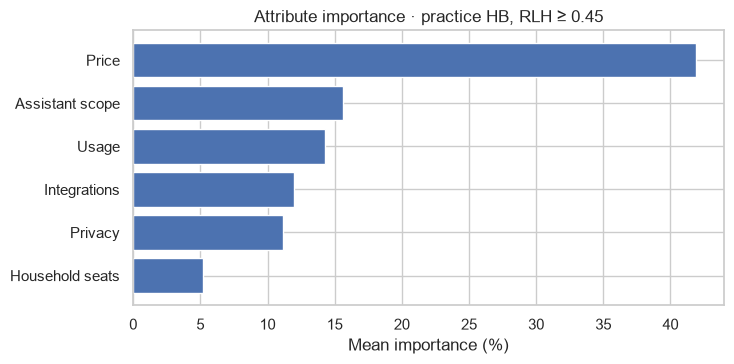

In [6]:
imp = importances(keep)
imp_overall = (imp.mean() * 100).sort_values(ascending=False).rename("importance_%")
print("Mean attribute importance (QA'd n = %s)" % len(keep))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.barh(imp_overall.index[::-1], imp_overall.values[::-1], color="#4C72B0")
ax.set_xlabel("Mean importance (%)")
ax.set_title("Attribute importance · practice HB, RLH ≥ 0.45")
fig.tight_layout()
imp_overall.to_frame()


### Two segments

**Professionals vs students** — the board will ask about a student plan. **Privacy-concern 4–5 vs 1–2** — tests whether Lantern's fence is a niche or a mass feature.


In [7]:
seg = {
    "All": keep,
    "Professional": keep[keep.occupation == "professional"],
    "Student": keep[keep.occupation == "student"],
    "Privacy 4–5": keep[keep.privacy_concern_1to5 >= 4],
    "Privacy 1–2": keep[keep.privacy_concern_1to5 <= 2],
}
imp_seg = pd.DataFrame({name: importances(g).mean() * 100 for name, g in seg.items()})
imp_seg = imp_seg.loc[["Price", "Assistant scope", "Usage", "Integrations", "Privacy", "Household seats"]]
print("n:", {k: len(v) for k, v in seg.items()})
imp_seg.round(1)


n: {'All': 391, 'Professional': 214, 'Student': 89, 'Privacy 4–5': 92, 'Privacy 1–2': 141}


,All,Professional,Student,Privacy 4–5,Privacy 1–2
Price,41.9,41.5,41.9,42.3,41.4
Assistant scope,15.6,14.9,15.7,14.3,16.0
Usage,14.3,14.7,16.8,12.1,16.1
Integrations,12.0,11.8,12.5,10.7,12.4
Privacy,11.1,12.7,8.2,16.4,8.6
Household seats,5.2,4.5,4.9,4.1,5.5


In [8]:
wtp_all = median_wtp_table(keep)
print("Median WTP $/month for each feature step (outliers do not move the median)")
wtp_all.style.format(
    {"median_$": "${:.2f}", "p25": "${:.2f}", "p75": "${:.2f}", "share_positive": "{:.0%}"}
)


Median WTP $/month for each feature step (outliers do not move the median)


,step,n,median_$,p25,p75,share_positive
0,Usage Light → Standard,391,$4.74,$3.04,$8.11,100%
1,Usage Standard → Max,391,$2.61,$0.60,$6.17,82%
2,Usage Light → Max,391,$6.99,$4.70,$14.00,100%
3,Privacy Standard → No-training,391,$4.00,$2.30,$6.01,100%
4,Privacy No-training → Vault,391,$2.53,$0.83,$4.76,85%
5,Privacy Standard → Vault,391,$6.39,$4.29,$10.24,100%
6,Agents Answers → Life-admin,391,$7.37,$5.53,$9.68,100%
7,Agents Life-admin → Autopilot,391,$2.98,$-0.51,$6.04,70%
8,Agents Answers → Autopilot,391,$10.27,$7.43,$12.92,99%
9,Integrations None → Email+cal,391,$5.19,$4.07,$6.60,100%


In [9]:
key = [
    ("Privacy Standard → No-training", "priv_2", "priv_1"),
    ("Privacy Standard → Vault", "priv_3", "priv_1"),
    ("Agents Answers → Life-admin", "agents_2", "agents_1"),
    ("Agents Life-admin → Autopilot", "agents_3", "agents_2"),
    ("Usage Light → Max", "usage_3", "usage_1"),
    ("Integrations None → Full suite", "integ_3", "integ_1"),
    ("Seats Individual → Household", "seats_2", "seats_1"),
]
wtp_seg = pd.DataFrame(
    {
        name: {label: wtp_step(g, b, a).median() for label, b, a in key}
        for name, g in seg.items()
    }
)
wtp_seg.style.format("${:.2f}")


,All,Professional,Student,Privacy 4–5,Privacy 1–2
Privacy Standard → No-training,$4.00,$4.41,$2.77,$6.63,$2.87
Privacy Standard → Vault,$6.39,$7.76,$4.59,$11.72,$5.31
Agents Answers → Life-admin,$7.37,$7.33,$6.88,$7.08,$7.15
Agents Life-admin → Autopilot,$2.98,$2.15,$4.19,$1.75,$3.79
Usage Light → Max,$6.99,$8.13,$7.47,$8.02,$6.63
Integrations None → Full suite,$8.02,$8.08,$8.23,$7.35,$8.23
Seats Individual → Household,$2.32,$2.11,$1.72,$2.16,$2.62


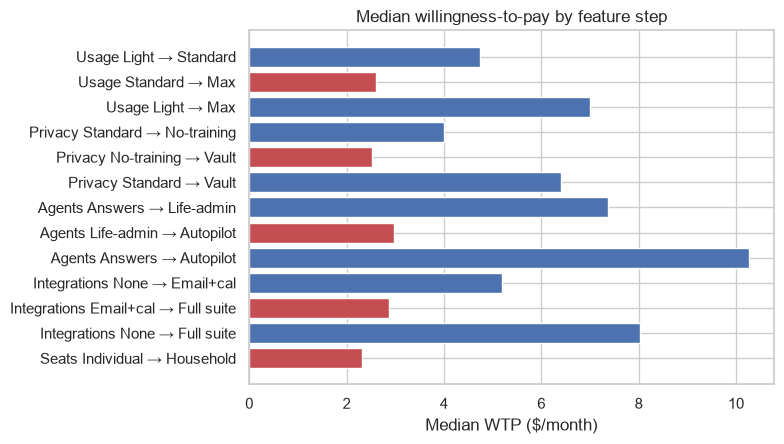

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.6))
plot = wtp_all.set_index("step")["median_$"].iloc[::-1]
colors = ["#C44E52" if v < 3 else "#4C72B0" for v in plot.values]
ax.barh(plot.index, plot.values, color=colors)
ax.set_xlabel("Median WTP ($/month)")
ax.set_title("Median willingness-to-pay by feature step")
fig.tight_layout()


### Most surprising WTP — three sentences

Privacy is Lantern's identity and only 11% of importance — fifth of six attributes. The median no-training premium is **$4.00**, not the $8 Week-1 bar; even privacy-sensitive professionals clear only **$7.94** (48% ≥ $8). I believe that number: high-concern respondents really do pay more ($6.63 vs $2.87 among the unconcerned), but not enough to make privacy the fence that carries a $20 plan.

What *does* carry it is **life-admin vs answers at $7.37** (100% positive) and **full integrations at $8.02**. Autopilot on top of life-admin is only $2.98, and **30% of respondents have negative WTP** for that step — they will pay to keep click-to-approve. Household seats are a real but small $2.32, which matches Week 2's finding that shared-device users clicked the banner *less*.

The $20 incumbent clone (Standard usage, standard privacy, answers only, no integrations, individual) wins first-choice against None for **4 of 391 respondents (1.0%)**. Firefly's 0.97% paid conversion is sitting in this file.


## 3. Hand-verify (Exhibit 10)

Two feature-step medians from raw utilities, then the 10-respondent first-choice count. If these do not match the workbook, stop — the rest of the notebook is wrong.


In [11]:
r1 = keep.loc[keep.Respondent_ID == 1].iloc[0]
wtp_r1_vault = (r1.priv_3 - r1.priv_1) / abs(r1["Price_per_+$10"]) * 10
wtp_r1_life = (r1.agents_2 - r1.agents_1) / abs(r1["Price_per_+$10"]) * 10
med_vault = wtp_step(keep, "priv_3", "priv_1").median()
med_life = wtp_step(keep, "agents_2", "agents_1").median()

print("Respondent 1 — Vault vs Standard")
print(f"  priv_3 = {r1.priv_3:.4f}   priv_1 = {r1.priv_1:.4f}   β_$10 = {r1['Price_per_+$10']:.4f}")
print(f"  WTP = ({r1.priv_3:.4f} − ({r1.priv_1:.4f})) / {abs(r1['Price_per_+$10']):.4f} × 10 = ${wtp_r1_vault:.4f}")
print(f"  Workbook Exhibit 10 = $13.5962   match = {np.isclose(wtp_r1_vault, 13.5961680176861)}")
print()
print("Respondent 1 — Life-admin vs Answers")
print(f"  WTP = ${wtp_r1_life:.4f}")
print()
print("Medians on the analytic sample (the memo numbers)")
print(f"  Privacy Standard → Vault     median ${med_vault:.2f}   (R1 is a high-side check, not the median)")
print(f"  Agents Answers → Life-admin  median ${med_life:.2f}")


Respondent 1 — Vault vs Standard
  priv_3 = 0.4020   priv_1 = -0.5205   β_$10 = -0.6785
  WTP = (0.4020 − (-0.5205)) / 0.6785 × 10 = $13.5962
  Workbook Exhibit 10 = $13.5962   match = True

Respondent 1 — Life-admin vs Answers
  WTP = $10.7900

Medians on the analytic sample (the memo numbers)
  Privacy Standard → Vault     median $6.39   (R1 is a high-side check, not the median)
  Agents Answers → Life-admin  median $7.37


In [12]:
# Home $20 = Light, No-training, Life-admin, Full suite, Household
# Pro  $24 = Standard, Vault, Life-admin, Full suite, Individual
rows = raw[raw.Respondent_ID.between(1, 10)].copy()
fc = []
for _, r in rows.iterrows():
    u_home = plan_utility(r, "usage_1", "priv_2", "agents_2", "integ_3", "seats_2", 20)
    u_pro = plan_utility(r, "usage_2", "priv_3", "agents_2", "integ_3", "seats_1", 24)
    u_none = r["NONE"]
    pick = ["Home", "Pro", "None"][int(np.argmax([u_home, u_pro, u_none]))]
    fc.append(
        {
            "Respondent": int(r.Respondent_ID),
            "U(Home $20)": u_home,
            "U(Pro $24)": u_pro,
            "U(None)": u_none,
            "First choice": pick,
        }
    )
fc = pd.DataFrame(fc)
print("Exhibit 10 target: R1 Pro, R9 Home, everyone else None")
print(fc["First choice"].value_counts().to_string())
fc.style.format({"U(Home $20)": "{:.4f}", "U(Pro $24)": "{:.4f}", "U(None)": "{:.4f}"})


Exhibit 10 target: R1 Pro, R9 Home, everyone else None
First choice
None    8
Pro     1
Home    1


,Respondent,U(Home $20),U(Pro $24),U(None),First choice
0,1,-1.3025,-0.8892,-1.0260,Pro
1,2,-1.7743,-1.5338,-0.4968,None
2,3,-1.6114,-2.2761,-1.5971,None
3,4,-1.9460,-2.9974,0.1574,None
4,5,-1.5624,-1.4769,2.3901,None
5,6,-1.3362,-1.8439,-0.2833,None
6,7,-2.2212,-1.8968,1.3614,None
7,8,-2.9031,-3.7199,-1.5022,None
8,9,-1.2596,-1.4222,-1.6902,Home
9,10,-2.9973,-2.0304,-0.7324,None


Workbook row 1: U(Home) = −1.3025, U(Pro) = −0.8892, U(None) = −1.026 → **Pro**. Row 9: Home. The other eight: None. Counts 1 / 1 / 8.

On the full analytic sample the same two-tier lineup is **5.1% Home / 14.6% Pro / 80.3% None**. Take rates × 124,000 are the $m$ inputs for Week 5, not anything from the 400,000 MAU.


In [13]:
picks = []
clone = []
for _, r in keep.iterrows():
    u_home = plan_utility(r, "usage_1", "priv_2", "agents_2", "integ_3", "seats_2", 20)
    u_pro = plan_utility(r, "usage_2", "priv_3", "agents_2", "integ_3", "seats_1", 24)
    u_clone = plan_utility(r, "usage_2", "priv_1", "agents_1", "integ_1", "seats_1", 20)
    u_none = r["NONE"]
    picks.append(["Home", "Pro", "None"][int(np.argmax([u_home, u_pro, u_none]))])
    clone.append("Clone" if u_clone > u_none else "None")
take = pd.Series(picks).value_counts(normalize=True)
clone_take = (pd.Series(clone) == "Clone").mean()
print("Home $20 / Pro $24 / None, n =", len(keep))
print(take.rename(lambda s: f"{s} take").map("{:.1%}".format).to_string())
print(f"implied m (× 124,000): Home {take.get('Home', 0)*QUALIFIED_POOL:,.0f}  "
      f"Pro {take.get('Pro', 0)*QUALIFIED_POOL:,.0f}")
print(f"$20 incumbent clone vs None: {clone_take:.2%}  (n = {int(clone_take * len(keep))})")


Home $20 / Pro $24 / None, n = 391
None take    80.3%
Pro take     14.6%
Home take     5.1%
implied m (× 124,000): Home 6,343  Pro 18,077
$20 incumbent clone vs None: 1.02%  (n = 4)


## 4. Silicon twin scorecard

Score **sealed Week 3 predictions** against these human actuals. Do not revise the sealed numbers. Accuracy is not graded; honesty is.

Human actuals from this file (the right-hand side of the scorecard):

| Prediction | Human (practice HB, n = 391) |
|---|---|
| Top-2 attributes by importance | **Price**, **Assistant scope** (41.9%, 15.6%) |
| Median WTP, Vault vs Standard | **$6.39 / month** |
| $20-clone take rate (first choice vs None) | **1.02%** (4 / 391) |

Week 3's `PREREG` cell is still `UNSEALED`. Fill `SILICON` below only from the 30-persona run, then compute the three errors. If silicon is not in, the scorecard stays blank on the silicon side — that is the honest state.


In [14]:
from datetime import timezone

HUMAN = {
    "top2": ["Price", "Assistant scope"],
    "importance_order": ["Price", "Assistant scope", "Usage", "Integrations", "Privacy", "Household seats"],
    "median_privacy_wtp": float(wtp_step(keep, "priv_3", "priv_1").median()),
    "clone20_take": float(clone_take),
}

# Paste Week 3 sealed numbers. Leave None until the 30 personas are scored.
SILICON = {
    "timestamp_utc": None,
    "top2": [None, None],
    "importance_order": None,  # list of 6 names, same labels as HUMAN["importance_order"]
    "median_privacy_wtp": None,
    "clone20_take": None,
}

if SILICON["timestamp_utc"] is None:
    print("Silicon still unsealed — reporting human actuals only.")
    scorecard = pd.Series(
        {
            "human_top2": ", ".join(HUMAN["top2"]),
            "human_privacy_WTP": HUMAN["median_privacy_wtp"],
            "human_clone20_take": HUMAN["clone20_take"],
            "importance_rank_corr": np.nan,
            "WTP_direction_hit": np.nan,
            "WTP_gap_$": np.nan,
            "clone_take_error_pp": np.nan,
        }
    )
else:
    # Spearman on the 6-attribute rank lists if provided
    if SILICON["importance_order"]:
        h_rank = {k: i for i, k in enumerate(HUMAN["importance_order"])}
        s_rank = {k: i for i, k in enumerate(SILICON["importance_order"])}
        keys = HUMAN["importance_order"]
        corr = pd.Series([h_rank[k] for k in keys]).corr(
            pd.Series([s_rank[k] for k in keys]), method="spearman"
        )
    else:
        corr = np.nan
    wtp_s = SILICON["median_privacy_wtp"]
    wtp_h = HUMAN["median_privacy_wtp"]
    scorecard = pd.Series(
        {
            "human_top2": ", ".join(HUMAN["top2"]),
            "silicon_top2": ", ".join(SILICON["top2"]),
            "human_privacy_WTP": wtp_h,
            "silicon_privacy_WTP": wtp_s,
            "WTP_direction_hit": int(np.sign(wtp_s) == np.sign(wtp_h)) if wtp_s is not None else np.nan,
            "WTP_gap_$": (wtp_s - wtp_h) if wtp_s is not None else np.nan,
            "human_clone20_take": HUMAN["clone20_take"],
            "silicon_clone20_take": SILICON["clone20_take"],
            "clone_take_error_pp": (
                (SILICON["clone20_take"] - HUMAN["clone20_take"]) * 100
                if SILICON["clone20_take"] is not None
                else np.nan
            ),
            "importance_rank_corr": corr,
        }
    )
scorecard


Silicon still unsealed — reporting human actuals only.


human_top2              Price, Assistant scope
human_privacy_WTP                     6.394893
human_clone20_take                     0.01023
importance_rank_corr                       NaN
WTP_direction_hit                          NaN
WTP_gap_$                                  NaN
clone_take_error_pp                        NaN
dtype: object

**Where silicon broke (three sentences, fill after the twin runs).** Until then: the human $20-clone take of 1% is the number a silicon respondent is most likely to miss — models that “help” the user will over-pick paid plans. Privacy WTP is the second trap: overall $6.39, $13.31 among privacy-sensitive professionals. A persona prompt that leans on Lantern's identity will overstate privacy importance (human rank: 5th). File the ugly version.


## 5. Week-1 hypothesis verdicts

Working M1 hypotheses (case example + Week 2 telemetry). Swap the wording if your Week 1 memo used different numbers — do not swap the *data*.

| # | Hypothesis | Number in this file | Verdict |
|---|---|---|---|
| H1 | Privacy-sensitive professionals pay ≥ $8/month more for a **no-training** guarantee | Median **$7.94** (n = 64); 48% ≥ $8. Vault vs Standard for the same people: **$13.31** | **Complicated.** Direction is right; the $8 bar is a near-miss on the small step and a clear hit on the Vault stack. |
| H2 | Life-admin agents (approve each action) are worth ≥ $5/month vs answers-only | Median **$7.37**, 100% positive, similar for students ($6.88) and professionals ($7.33) | **Confirmed.** This is the fence that actually moves utility. |
| H3 | Household seats are worth ≥ $5/month (22% of MAU share a device) | Median **$2.32**; professionals $2.11; students $1.72 | **Killed.** Positive, not material. Do not build a tier around household. |

H1 in arithmetic: among occupation = professional and privacy concern ≥ 4, median $(u_{\text{no-training}} - u_{\text{standard}}) / |\beta_{\$10}| \times 10 = \$7.94$. The hypothesis named *no-training*, not Vault. Calling it confirmed would be moving the goalposts.


In [15]:
psp = keep[(keep.occupation == "professional") & (keep.privacy_concern_1to5 >= 4)]
h1 = wtp_step(psp, "priv_2", "priv_1")
h1_vault = wtp_step(psp, "priv_3", "priv_1")
h2 = wtp_step(keep, "agents_2", "agents_1")
h3 = wtp_step(keep, "seats_2", "seats_1")
verdicts = pd.DataFrame(
    [
        ["H1 no-training ≥ $8 among privacy-sensitive professionals",
         len(psp), h1.median(), (h1 >= 8).mean(), "Complicated"],
        ["H1b Vault vs Standard, same people (not the named hyp)",
         len(psp), h1_vault.median(), (h1_vault >= 8).mean(), "—"],
        ["H2 life-admin vs answers ≥ $5, overall",
         len(keep), h2.median(), (h2 >= 5).mean(), "Confirmed"],
        ["H3 household ≥ $5, overall",
         len(keep), h3.median(), (h3 >= 5).mean(), "Killed"],
    ],
    columns=["hypothesis", "n", "median_WTP", "share_at_bar", "verdict"],
)
verdicts.style.format({"median_WTP": "${:.2f}", "share_at_bar": "{:.1%}"})


,hypothesis,n,median_WTP,share_at_bar,verdict
0,H1 no-training ≥ $8 among privacy-sensitive professionals,64,$7.94,48.4%,Complicated
1,"H1b Vault vs Standard, same people (not the named hyp)",64,$13.31,82.8%,—
2,"H2 life-admin vs answers ≥ $5, overall",391,$7.37,82.1%,Confirmed
3,"H3 household ≥ $5, overall",391,$2.32,33.0%,Killed


## Memo copy-paste

**1. Fielding / QA.** Practice HB n = 400. Dropped 9 respondents with RLH < 0.45 (all professionals; IDs in the QA log). Analytic n = **391 ≥ 60**. Occupation 54.7% professional / 22.8% student / 22.5% other vs 56 / 21 / 23 quota. No speeder or straightliner flags exist on this file.

**2. Preference read.** Mean importances: Price 41.9%, assistant scope 15.6%, usage 14.3%, integrations 12.0%, privacy 11.1%, household 5.2%. Median WTP: Light→Standard $4.74; Standard→Max $2.61; Standard→no-training $4.00; no-training→Vault $2.53; Standard→Vault $6.39; Answers→life-admin **$7.37**; life-admin→Autopilot $2.98 (30% negative); None→full suite $8.02; Individual→Household $2.32. Professionals put more weight on privacy (12.7% vs students 8.2%); students remain price-tied. Most surprising: privacy is not the #1 fence, Autopilot is optional, and a $20 clone takes **1%**.

**3. Hand-verify.** R1 Vault vs Standard: $(0.402 - (-0.5205)) / 0.6785 \times 10 = \$13.60$, matches Exhibit 10. Medians on n = 391: Vault step $6.39, life-admin step $7.37. First-choice on respondents 1–10 of {Home $20, Pro $24, None}: 1 Home, 1 Pro, 8 None, matching the workbook row by row.

**4. Silicon.** Human actuals: top-2 Price & assistant scope; median Vault-vs-Standard WTP $6.39; $20-clone take 1.02%. Sealed silicon predictions: *not yet filed.* Score them against these numbers, not a revised set.

**5. Hypotheses.** H1 complicated ($7.94 vs $8). H2 confirmed ($7.37). H3 killed ($2.32). Bridge: take rates in this file × 124,000 = Bass $m$. A $20 clone is not a business.
